View Column Names

In [ ]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'product_id', 'Amount',
       'TransactionID'],
      dtype='object')


Load the Dataset

In [ ]:
import pandas as pd
df = pd.read_csv("LTVprediction.csv")
print(df.head())
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  product_id  \
0  12-01-2010 08:26       2.55       17850  United Kingdom  B07JW9H4J1   
1  12-01-2010 08:26       3.39       17850  United Kingdom  B098NS6PVG   
2  12-01-2010 08:26       2.75       17850  United Kingdom  B096MSW6CT   
3  12-01-2010 08:26       3.39       17850  United Kingdom  B08HDJ86NZ   
4  12-01-2010 08:26       3.39       17850  United Kingdom  B08CF3B7N1   

       Amount TransactionID  
0  455.862764            T1  
1  258.306546            T2  
2  212.015651            T3  
3 

Data Cleaning

In [ ]:
df.dropna(subset=["CustomerID"], inplace=True)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df = df[df["Amount"] > 0] 

Feature Engineering (RFM + AOV)

In [ ]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": [lambda x: (snapshot_date - x.max()).days, 
                    lambda x: (x.max() - x.min()).days],       
    "InvoiceNo": "nunique",                                   
    "Amount": ["sum", "mean"]                                
})
rfm.columns = ["Recency", "Tenure", "Frequency", "MonetaryValue", "AOV"]
rfm.reset_index(inplace=True)


Define Target Variable (LTV)

In [ ]:
rfm["LTV"] = rfm["MonetaryValue"] 

Split Features and Target

In [ ]:
from sklearn.model_selection import train_test_split
X = rfm[["Recency", "Tenure", "Frequency", "AOV"]]
y = rfm["LTV"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train Regression Model (XGBoost)

In [ ]:
from xgboost import XGBRegressor
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 2507.76
RMSE: 2585.21


 Predict LTV for All Customers

In [ ]:
rfm["Predicted_LTV"] = model.predict(X)

Customer Segmentation

In [ ]:
rfm["Segment"] = pd.qcut(rfm["Predicted_LTV"], q=3, labels=["Low", "Medium", "High"])

Visualizations

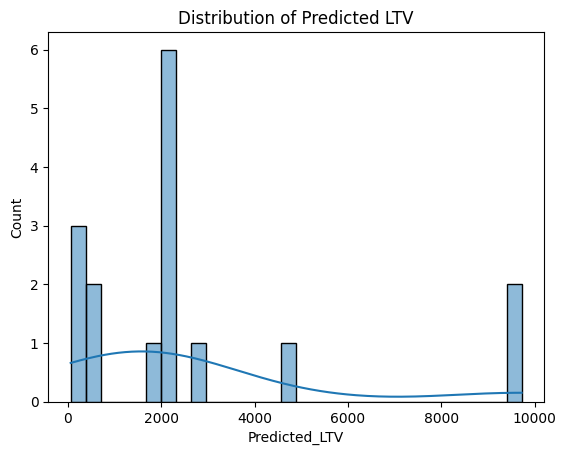

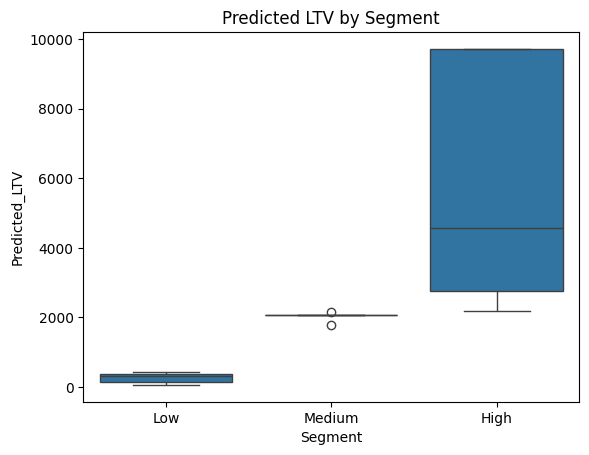

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(rfm["Predicted_LTV"], bins=30, kde=True)
plt.title("Distribution of Predicted LTV")
plt.show()

sns.boxplot(x="Segment", y="Predicted_LTV", data=rfm)
plt.title("Predicted LTV by Segment")
plt.show()


Save Deliverables

In [20]:
import joblib
joblib.dump(model, "ltv_model.pkl")


['ltv_model.pkl']

In [21]:
rfm[["CustomerID", "Predicted_LTV", "Segment"]].to_csv("Final_LTV_Predictions.csv", index=False)
